In [16]:
import numpy as np
import matplotlib.pyplot as plt
# import mkl

np.random.seed(1234)
# mkl.set_num_threads(2)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

In [17]:
def append_ones(matrix, axis=1):
    ones = np.ones((matrix.shape[0], 1), dtype=matrix.dtype)
    return np.concatenate((matrix, ones), axis=axis)

In [18]:
# one layer feed forward
def feed_forward(W, dataset, activation_fun):
    z = dataset @ W
    y = activation_fun(z)
    return y

In [19]:
# sigmoid activation function
def sigmoid(matrix):
    activations = 1 / (1 + np.exp(-matrix))
    return activations

In [20]:
# arrange 2D matrices as tiles (takes 4D `examples` tensor with dims: rows x cols x tile_height x tile_width)
def tiles(examples):
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]
    
    space_between_tiles = 2

    img_height = rows_count * tile_height + (rows_count - 1) * space_between_tiles
    img_width = cols_count * tile_width + (cols_count - 1) * space_between_tiles

    img_matrix = np.empty((img_height, img_width))
    img_matrix.fill(np.nan)

    for row in range(rows_count):
        for col in range(cols_count):
            start_y = row * (tile_height + space_between_tiles)
            end_y = start_y + tile_height

            start_x = col * (tile_width + space_between_tiles)
            end_x = start_x + tile_width

            img_matrix[start_y:end_y, start_x:end_x] = examples[row, col]
    
    return img_matrix

In [21]:
class Rbm:
    def __init__(self, visible_size, hidden_size, learning_rate):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.W = np.random.normal(scale=0.01, size=(visible_size+1, hidden_size+1)).astype(np.float32)
        self.W[:, -1] = 0.0
        self.W[-1, :] = 0.0

In [22]:
import mnists

mnist = mnists.MNIST()

import pickle
import seaborn as sns

with open("./lab1_rbm.pickle.dat", "rb") as f:
    rbm = pickle.load(f)

DATASET_SIZE = 512
DIGIT_SIZE = 28
mnist_dataset = mnist.test_images().astype(np.float32)
np.random.shuffle(mnist_dataset)
mnist_dataset = (mnist_dataset[:DATASET_SIZE] / 255.0).reshape(
    DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE
)
mnist_dataset = append_ones(mnist_dataset)

/var/folders/l1/7bh364895gg8nssghh2l23dh0000gn/T/ipykernel_8780/2469845828.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  rbm = pickle.load(f)


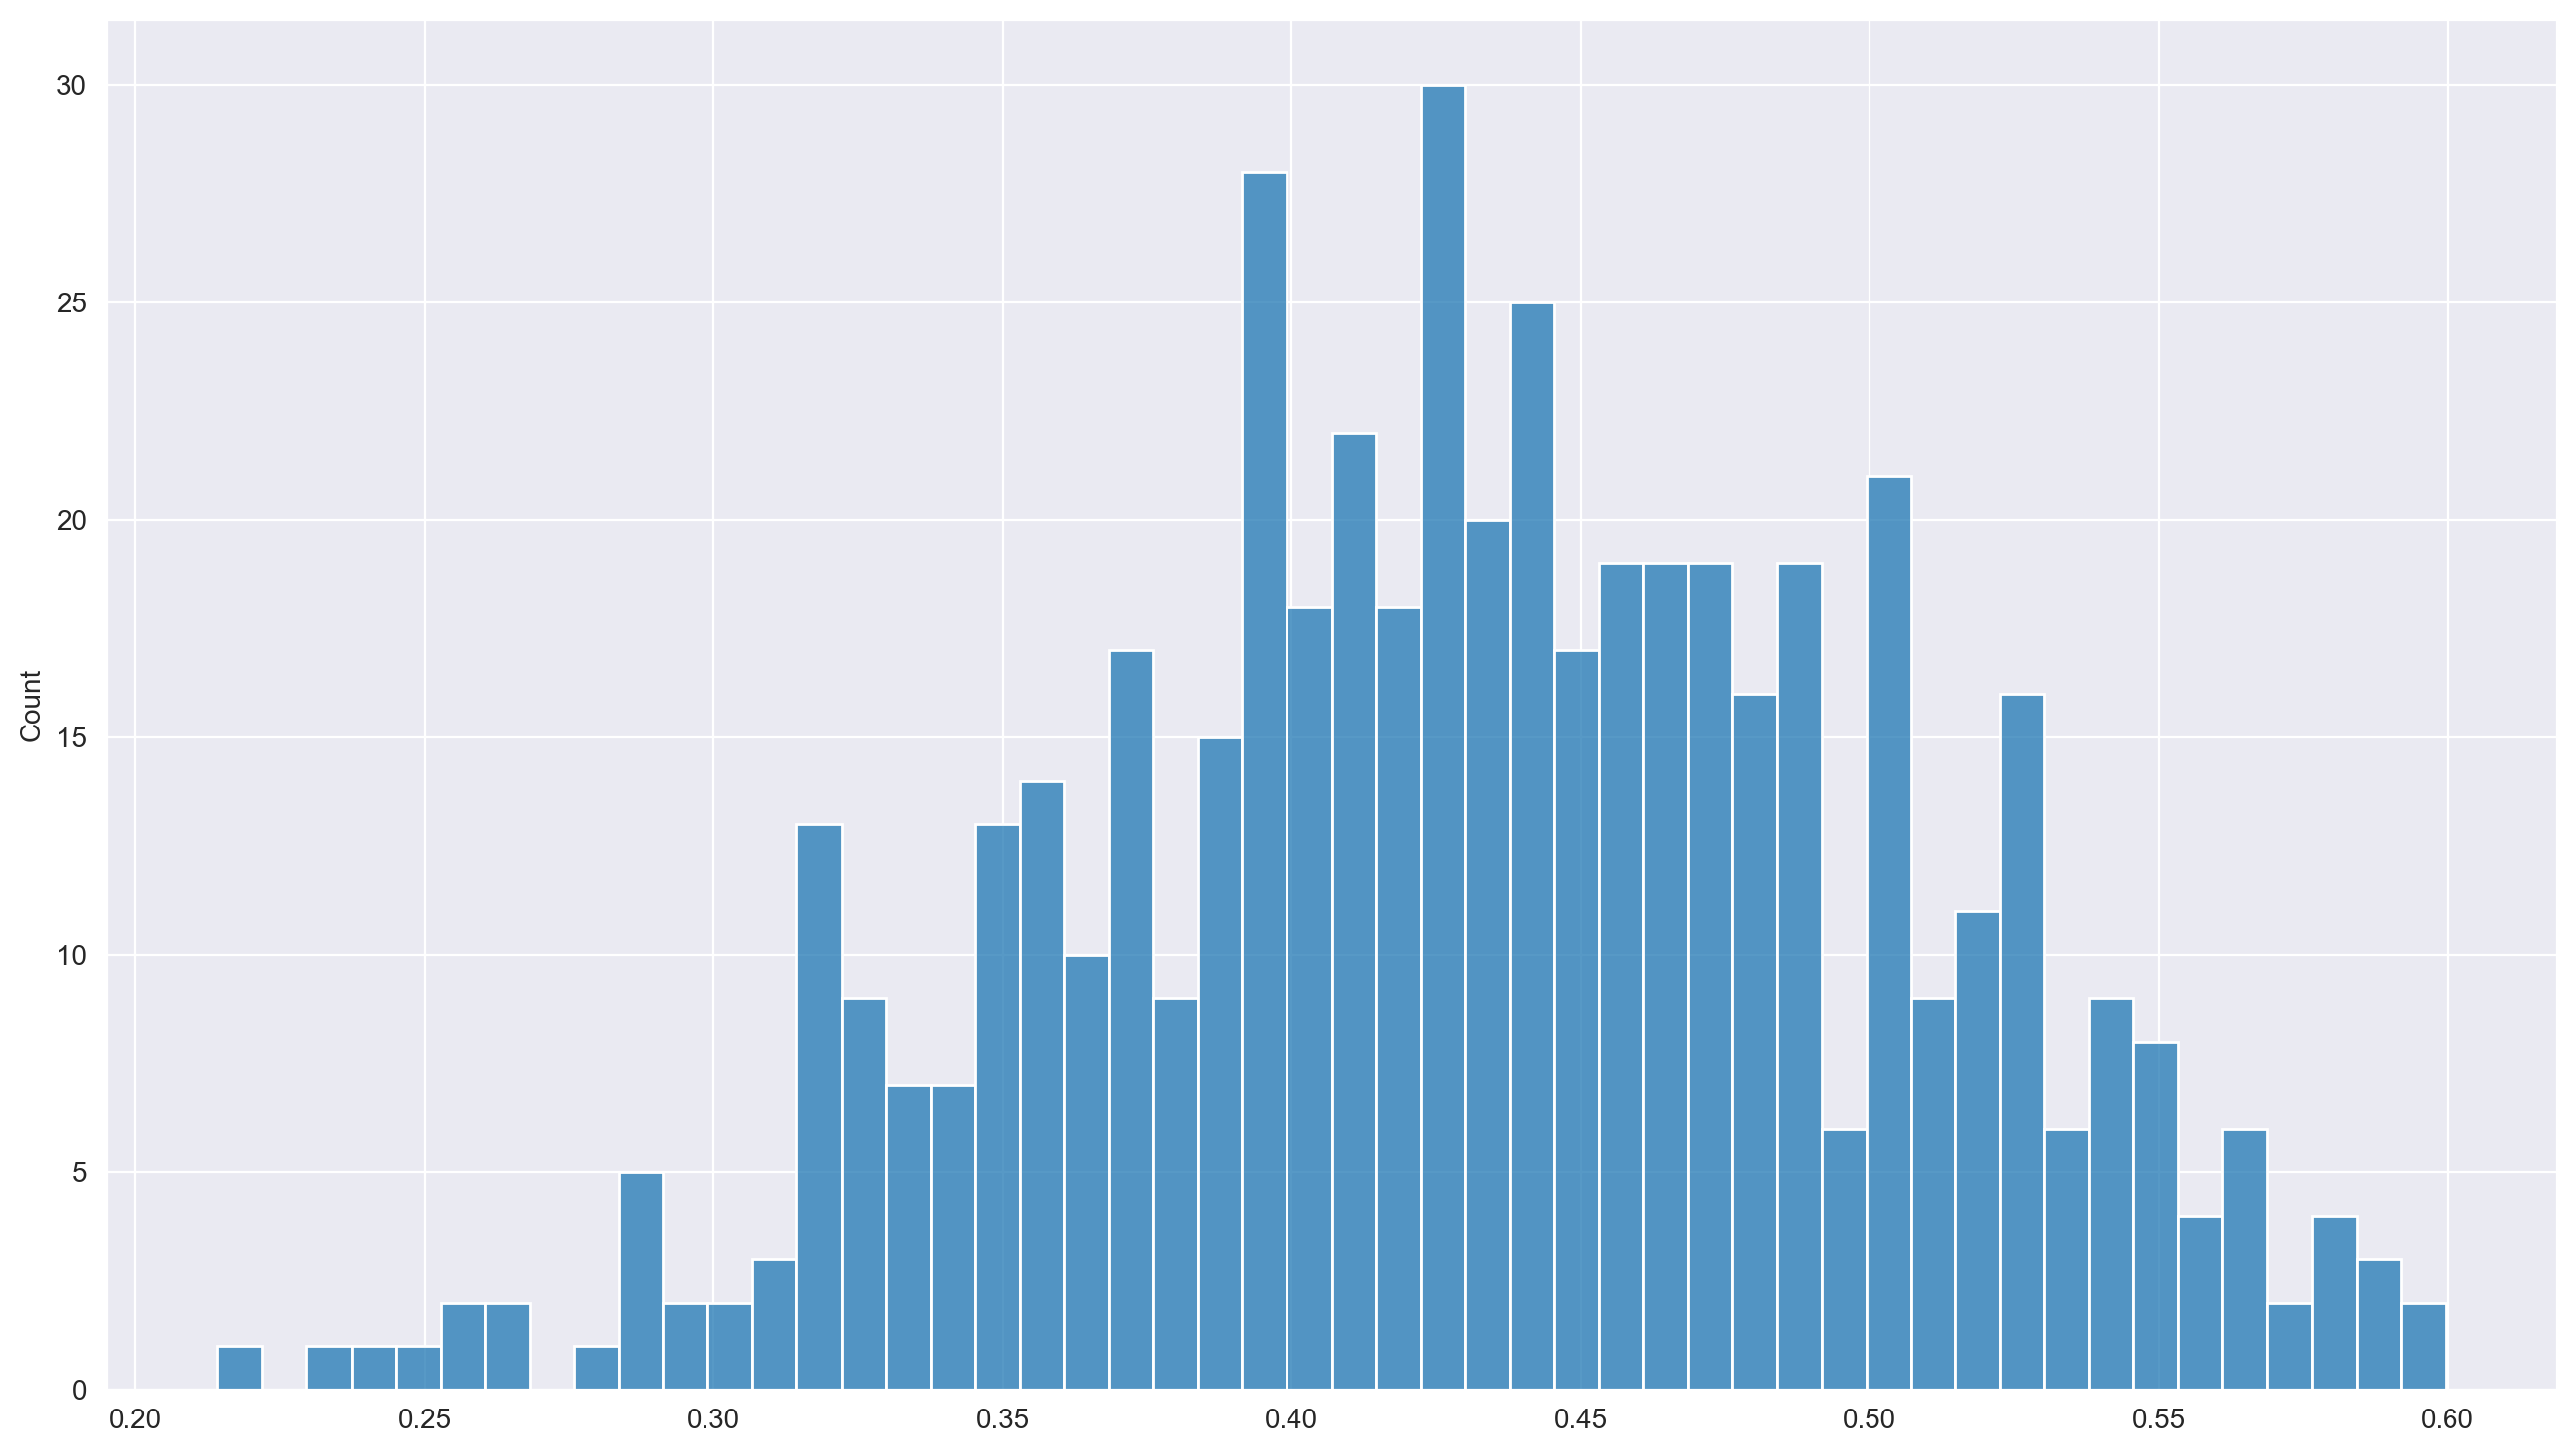

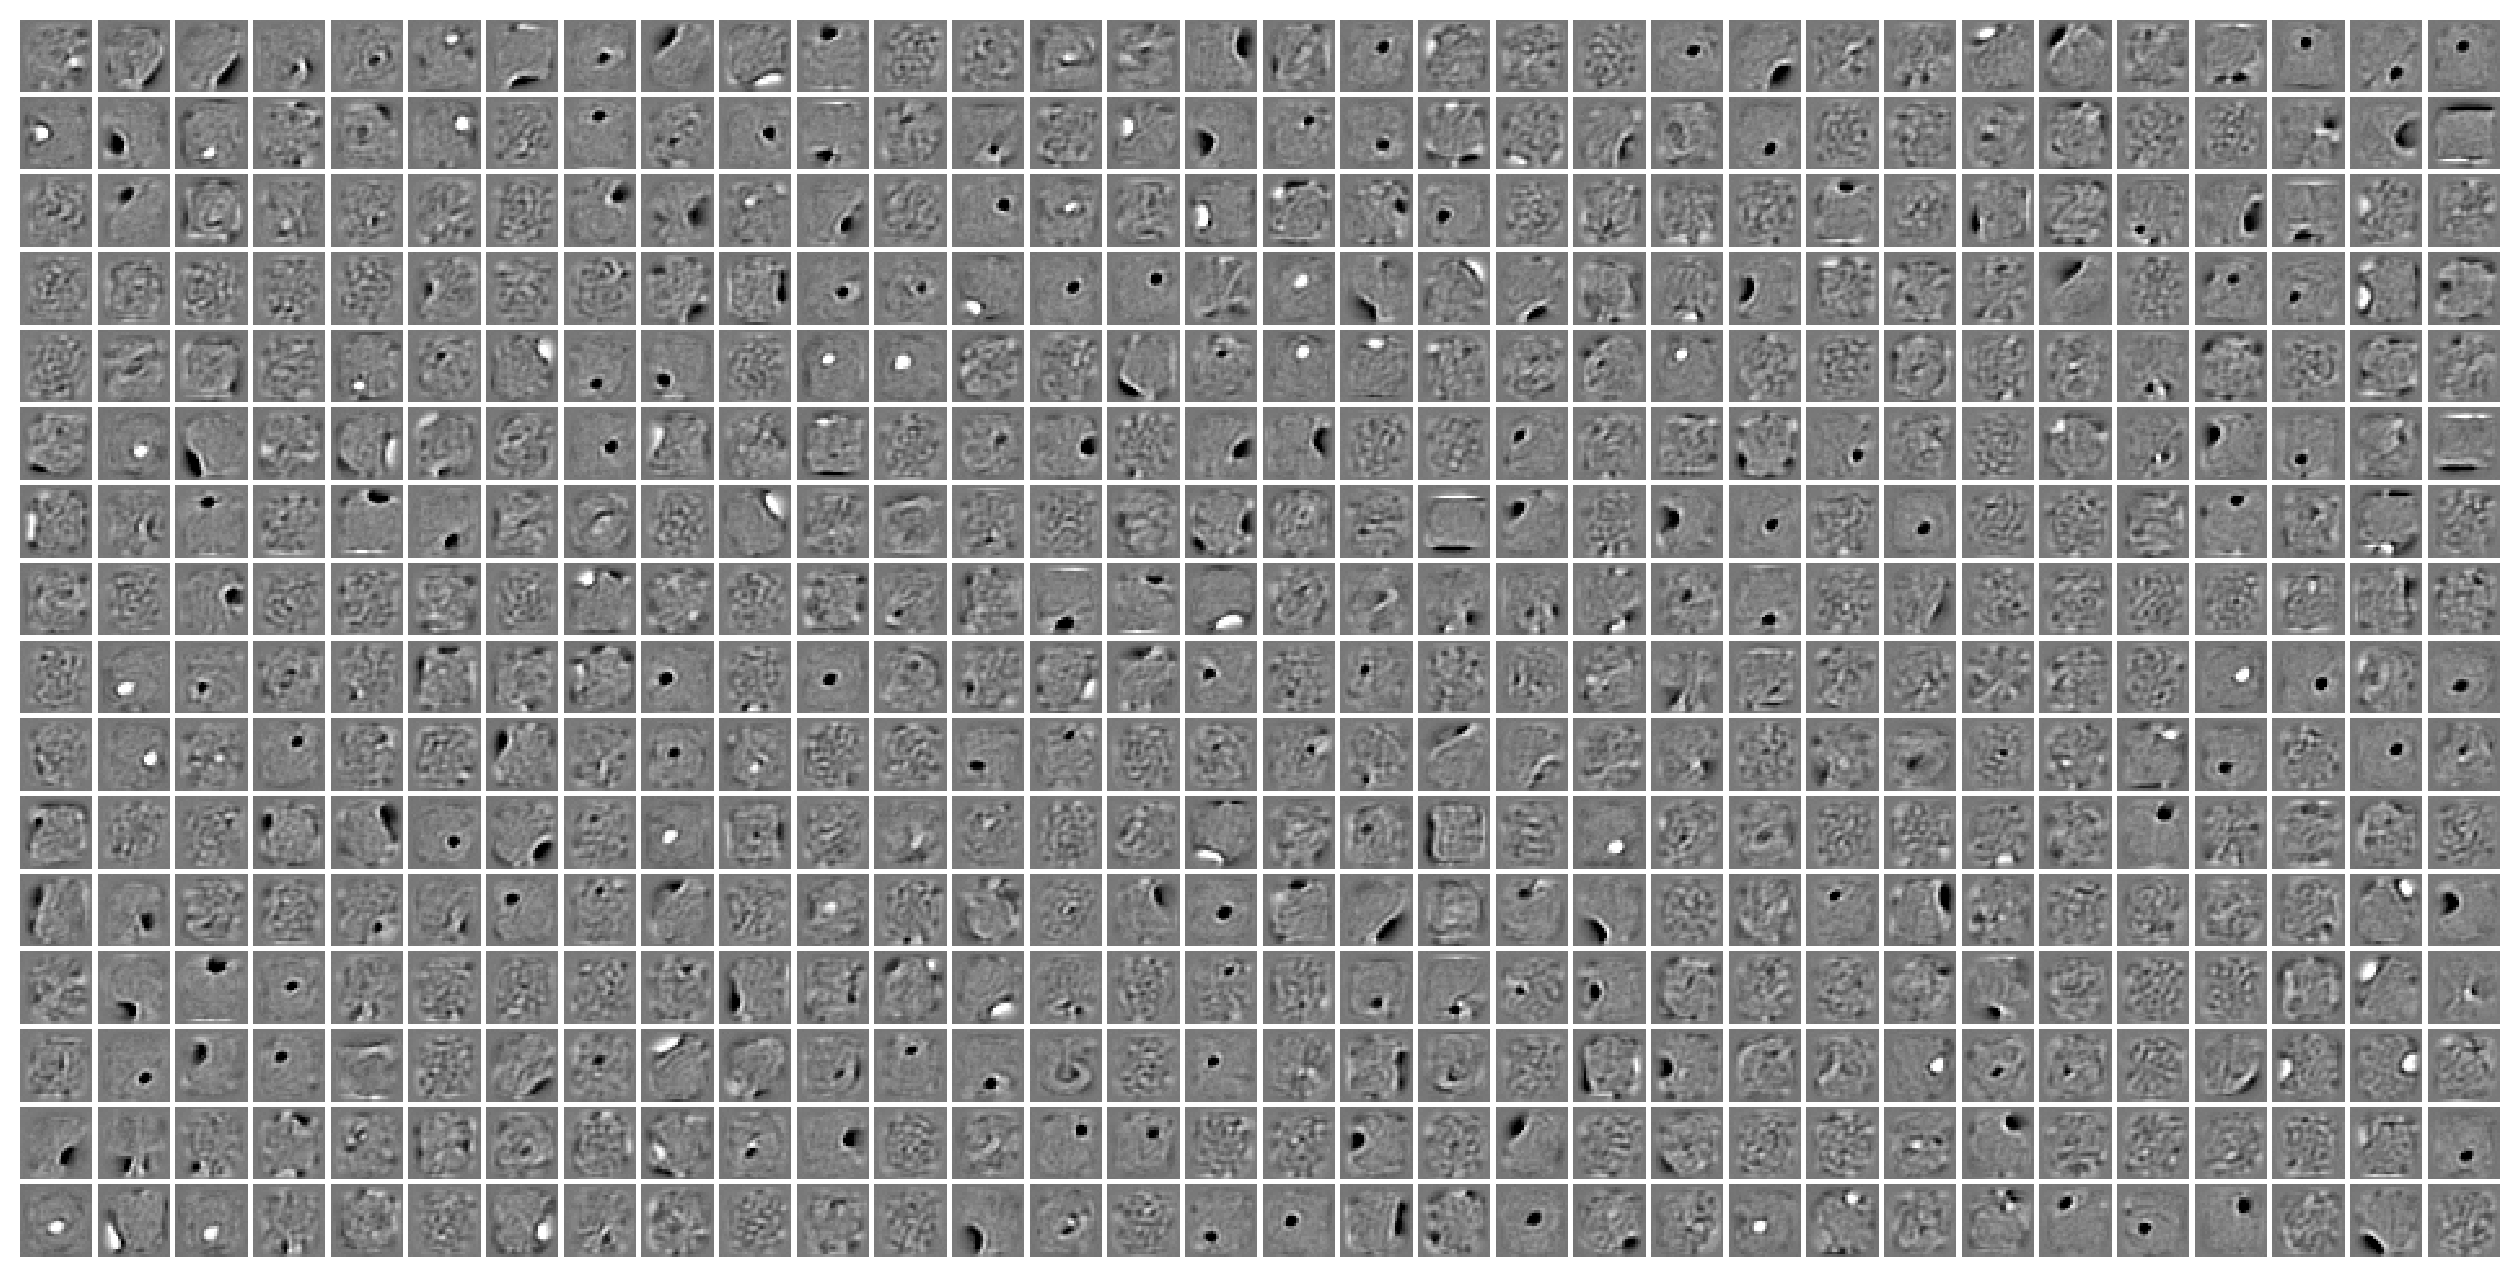

In [23]:
# Plotting mean hidden activations
activations = feed_forward(rbm.W, mnist_dataset, sigmoid)
mean_activations = np.mean(activations, axis=1)
sns.histplot(mean_activations, bins=50)

# Displaying RBM filters
filters = np.reshape(
    np.transpose(rbm.W)[:-1, :-1],
    (16, -1, 28, 28)
)
filters = np.clip(filters, -1.0, 1.0)

img = tiles(filters)
plt.matshow(img, cmap='gray', interpolation='none')
plt.axis('off')
plt.show()

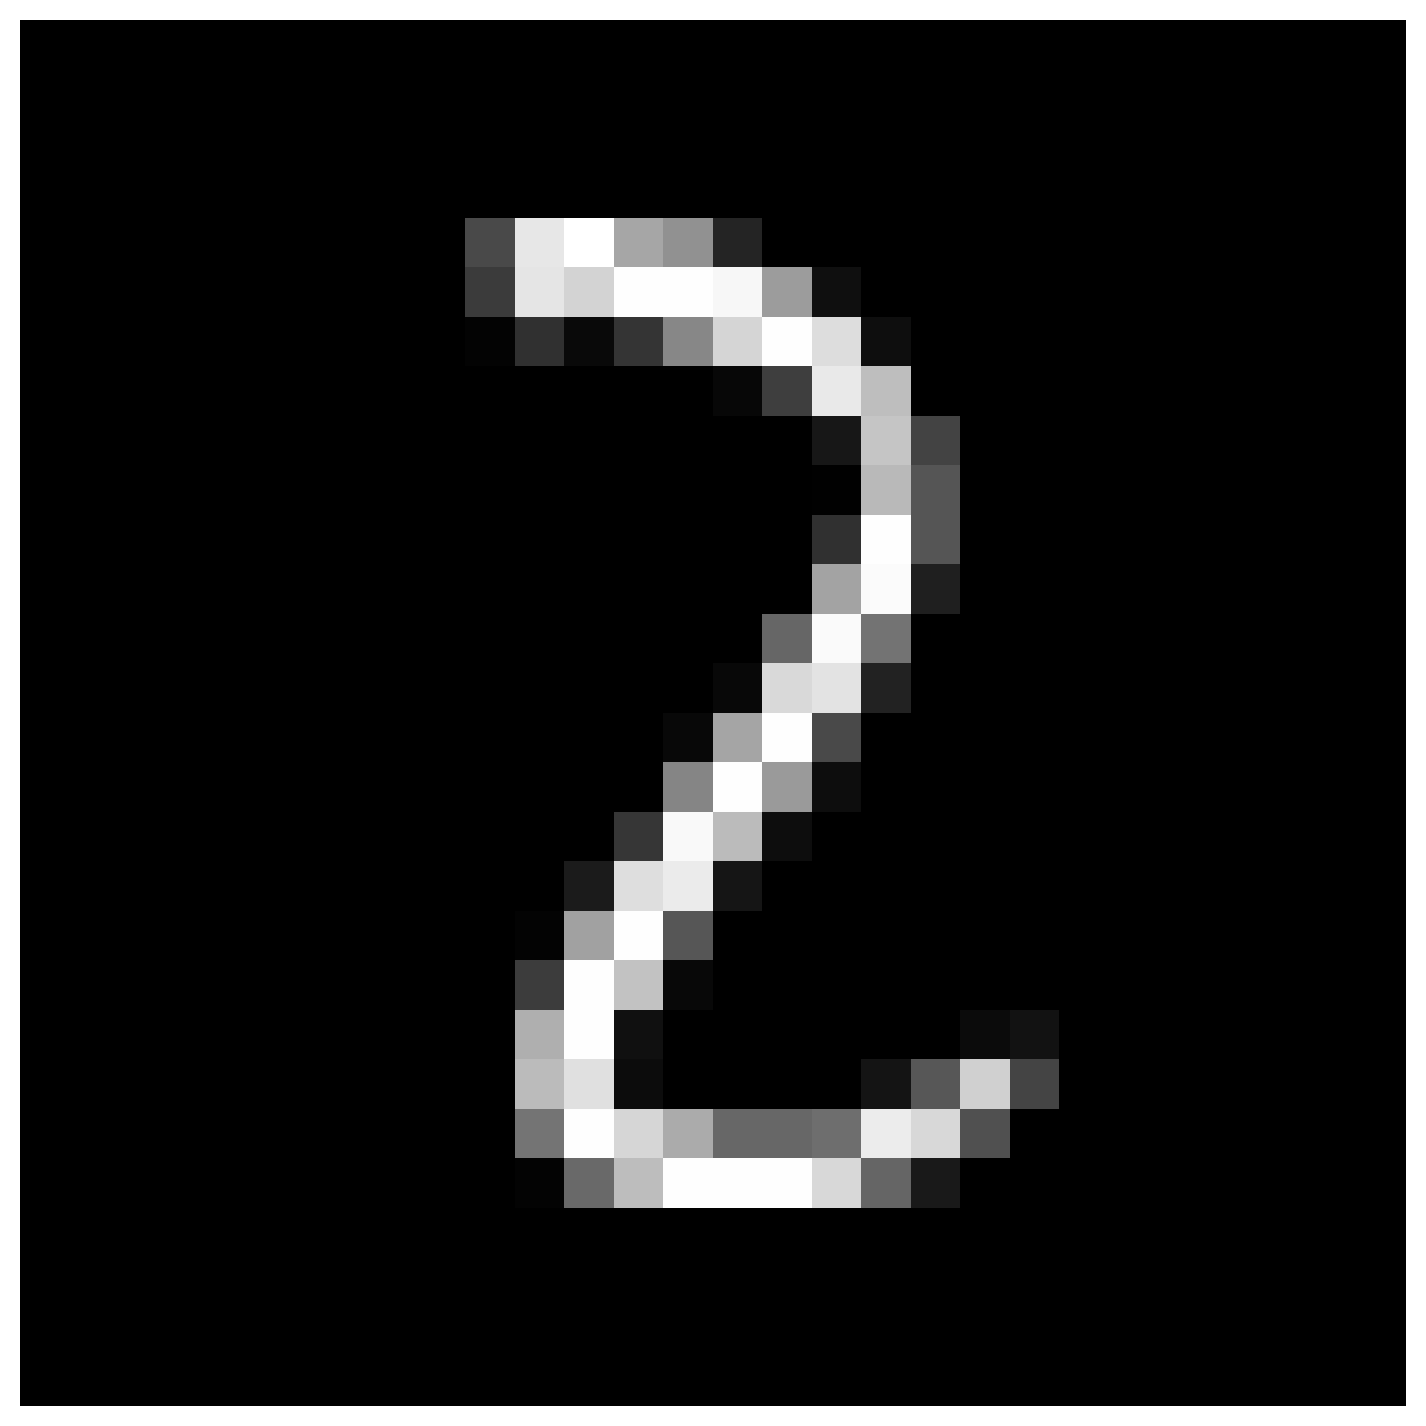

In [24]:
plt.imshow(mnist_dataset[0][:-1].reshape(28, 28), cmap="gray")
plt.axis("off")
plt.show()